# Local Outlier Factor (LOF) for DDoS Detection - Revised

### Key Changes in this Version:
1. **Realistic Contamination Thresholds:** Lowered the `contamination` search grid values. Because the model is trained *only* on normal traffic, high contamination values (like 0.1) force the model to flag 10% of normal traffic as attacks. We now test `0.001` to `0.05`.
2. **FPR-Aware Evaluation:** Replaced generic Precision/Recall with **False Positive Rate (FPR)** and **DDoS Detection Rate**. In network security, keeping the FPR close to 0% is often more critical than a slight boost in detecting anomalies.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    f1_score
)

In [2]:
# Load the dataset
df = pd.read_csv("../data/ddos_clean.csv")

# Create binary anomaly label (1 for DDoS, 0 for BENIGN)
df["Anomaly"] = (df[" Label"] != "BENIGN").astype(int)

# Separate features and target
X = df.drop([" Label", "Anomaly"], axis=1)
y_true = df["Anomaly"]

print("Dataset shape:", df.shape)
print(y_true.value_counts())

Dataset shape: (223082, 44)
Anomaly
1    128014
0     95068
Name: count, dtype: int64


In [3]:
# Separate BENIGN and DDoS samples
X_benign = X[y_true == 0]
X_ddos = X[y_true == 1]

# Split BENIGN data: 70% for training, 30% for testing
X_benign_train, X_benign_test = train_test_split(
    X_benign, test_size=0.3, random_state=42
)

print("BENIGN training samples:", X_benign_train.shape)
print("BENIGN test samples:", X_benign_test.shape)
print("DDoS test samples :", X_ddos.shape)

BENIGN training samples: (66547, 42)
BENIGN test samples: (28521, 42)
DDoS test samples : (128014, 42)


In [4]:
# Fit scaler ONLY on BENIGN training data (prevents data leakage)
scaler = StandardScaler()
scaler.fit(X_benign_train)

# Transform all sets using the scaler fitted on training data only
X_train_scaled = scaler.transform(X_benign_train)
X_benign_test_scaled = scaler.transform(X_benign_test)
X_ddos_test_scaled = scaler.transform(X_ddos)

# Build the BALANCED test set
X_test = np.vstack([X_benign_test_scaled, X_ddos_test_scaled])
y_test = np.concatenate([
    np.zeros(len(X_benign_test_scaled)),
    np.ones(len(X_ddos_test_scaled))
]).astype(int)

print("Final training set (BENIGN only):", X_train_scaled.shape)
print("Final test set:", X_test.shape)

Final training set (BENIGN only): (66547, 42)
Final test set: (156535, 42)


In [5]:
def evaluate_lof(n_neighbors, contamination, X_train, X_test, y_test):
    model = LocalOutlierFactor(
        n_neighbors=n_neighbors,
        novelty=True,
        contamination=contamination
    )
    model.fit(X_train)

    y_pred = (model.predict(X_test) == -1).astype(int)

    # Extract confusion matrix values
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    # REVISION 3: Calculate security-focused metrics
    fpr = fp / (fp + tn)                  # False Positive Rate (Alarm Fatigue)
    benign_acc = tn / (tn + fp)           # Specificity
    ddos_detection_rate = tp / (tp + fn)  # Sensitivity / Recall for DDoS
    f1 = f1_score(y_test, y_pred)

    return {
        "n_neighbors": n_neighbors,
        "contamination": contamination,
        "FPR": fpr,
        "Benign_Acc": benign_acc,
        "DDoS_Detection_Rate": ddos_detection_rate,
        "F1": f1
    }

In [6]:
# REVISION 2: Tune with realistic, low contamination rates 
# Since training data is 100% normal, expected outliers are near 0%.
neighbors_list = [20, 50, 100]
contamination_list = [0.001, 0.005, 0.01, 0.05]

results = []

for n in neighbors_list:
    for c in contamination_list:
        print(f"Testing n_neighbors={n}, contamination={c}...")
        res = evaluate_lof(n, c, X_train_scaled, X_test, y_test)
        results.append(res)

Testing n_neighbors=20, contamination=0.001...


Testing n_neighbors=20, contamination=0.005...


Testing n_neighbors=20, contamination=0.01...


Testing n_neighbors=20, contamination=0.05...


Testing n_neighbors=50, contamination=0.001...


...

Testing n_neighbors=50, contamination=0.05...


Testing n_neighbors=100, contamination=0.001...


Testing n_neighbors=100, contamination=0.005...


Testing n_neighbors=100, contamination=0.01...


Testing n_neighbors=100, contamination=0.05...


In [7]:
summary = pd.DataFrame(results)
summary["FPR"] = (summary["FPR"] * 100).round(2).astype(str) + "%"
summary["Benign_Acc"] = summary["Benign_Acc"].round(4)
summary["DDoS_Detection_Rate"] = summary["DDoS_Detection_Rate"].round(4)
summary["F1"] = summary["F1"].round(4)
# Display results, prioritizing models with the highest F1 but keeping an eye on FPR
print("Parameter Grid Results (Sorted by F1):")
print(summary.sort_values(by="F1", ascending=False).reset_index(drop=True))

Parameter Grid Results (Sorted by F1):
    n_neighbors  contamination    FPR  Benign_Acc  DDoS_Detection_Rate      F1
0            20          0.050  5.17%      0.9483               0.9254  0.9555
1            50          0.050  5.03%      0.9497               0.7370  0.8432
2           100          0.050  5.04%      0.9496               0.6987  0.8172
3            50          0.010  0.97%      0.9903               0.0045  0.0090
4           100          0.010  0.87%      0.9913               0.0028  0.0056
5            20          0.010  0.98%      0.9902               0.0005  0.0011
6            50          0.005  0.52%      0.9948               0.0003  0.0006
7            20          0.005   0.5%      0.9950               0.0003  0.0005
8           100          0.005  0.45%      0.9955               0.0000  0.0001
9            20          0.001  0.06%      0.9994               0.0000  0.0000
10           50          0.001  0.13%      0.9987               0.0000  0.0000
11          1


Training final LOF model with n_neighbors=20, contamination=0.05



Final Classification Report :
              precision    recall  f1-score   support

  BENIGN (0)       0.74      0.95      0.83     28521
    DDoS (1)       0.99      0.93      0.96    128014

    accuracy                           0.93    156535
   macro avg       0.86      0.94      0.89    156535
weighted avg       0.94      0.93      0.93    156535



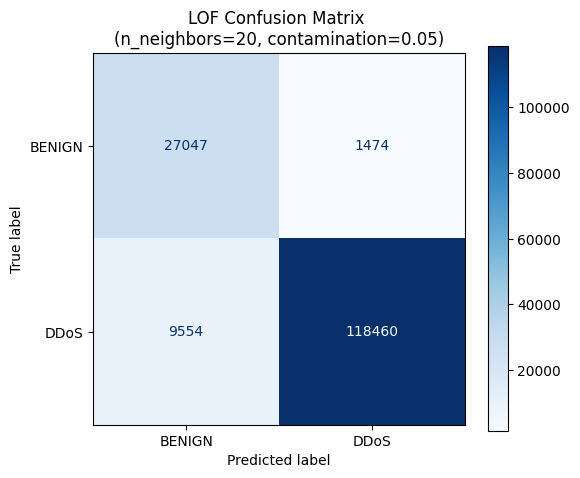

In [8]:
# Select the best model balancing high Detection Rate with a very low FPR.
# You can adjust the iloc[0] to pick a model with specifically lower FPR if desired.
best_params = summary.sort_values(by="F1", ascending=False).iloc[0]
best_n = int(best_params["n_neighbors"])
best_c = best_params["contamination"]

print(f"\nTraining final LOF model with n_neighbors={best_n}, contamination={best_c}")

best_lof = LocalOutlierFactor(n_neighbors=best_n, novelty=True, contamination=best_c)
best_lof.fit(X_train_scaled)
y_pred = (best_lof.predict(X_test) == -1).astype(int)

print("\nFinal Classification Report :")
print(classification_report(y_test, y_pred, target_names=["BENIGN (0)", "DDoS (1)"]))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["BENIGN", "DDoS"],
    cmap="Blues", values_format='d', ax=ax
)
plt.title(f"LOF Confusion Matrix \n(n_neighbors={best_n}, contamination={best_c})")
plt.show()